# Predictive Maintenance - Induction Motor
### Starter Notebook (Step 2 - Model Development)

This notebook is a continuation from 2 final dataset files:
- `client_training_dataset.csv` - COMPLETE (sensors + Motor_State 4-level: Normal/Warning/Critical/Failure + Fault_Type_True + RUL_hours + Health_Score + Probable_Cause + Recommended_Action). All labels are calculated retrospectively from historical data (Step 1 - Base Monitoring + Expert Labeling), used for **training**.
- `raw_sensor_new_data.csv` - RAW sensors only, WITHOUT any labels. This simulates new incoming real-time data from the factory, used for **testing the inference pipeline**.

**Workflow in this notebook:**
1. Load and inspect training data
2. Feature engineering (rolling statistics, delta, vibration combinations, voltage imbalance)
3. Verify RUL and Health_Score (already available in the file, calculated retrospectively from historical data)
4. Split data per motor with stratified sampling per fault class (prevent data leakage and missing classes)
5. Preprocessing and scaling
6. **Fault_Type_True** classification model - compare Random Forest vs XGBoost
7. **RUL** regression model - compare Random Forest vs Gradient Boosting
8. Recommendation engine (rule-based, English)
9. Save models
10. **End-to-end inference on `raw_sensor_new_data.csv`** - simulate real production conditions

> Replace the CSV path in the "Load Data" cell according to your file location in Google Drive or manual upload.

**Why are they separated into 2 files?** `Motor_State` and `Fault_Type_True` are human-defined (expert) labels based on historical data - this is VALID in training data because the model needs the "answer key" to learn. However, when this system is live in the factory, incoming real-time data will never have those labels (because that is exactly what the model is trying to predict) - hence the need to simulate this through `raw_sensor_new_data.csv` which contains pure sensor data without labels.

## 0. Setup
Install dependencies that are not present in the default Colab environment (xgboost is usually not present).

In [1]:
!pip install -q xgboost joblib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split  # generic utility, not the main split method used below
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBClassifier
import joblib

pd.set_option('display.max_columns', None)

## 1. Load Data

There are now two separate files:
- `client_training_dataset.csv` - COMPLETE (sensor + Motor_State 4-level + Fault_Type_True +
RUL_hours + Health_Score + Probable_Cause + Recommended_Action). Used for training.
- `raw_sensor_new_data.csv` - ONLY the sensor, without any labels. Simulating new factory data,
used for testing the inference pipeline at the end of the notebook.

**Option A - Manual upload to Colab:**
```python
from google.colab import files
uploaded = files.upload() # select both files above
```

**Option B - Mount Google Drive (recommended if the file is already saved to Drive):**
```python
from google.colab import drive
drive.mount('/content/drive')
```
Then adjust the path below to your file location.

In [3]:
TRAIN_DATA_PATH = "datasets/client_training_dataset.csv"  
RAW_DATA_PATH = "datasets/raw_sensor_new_data.csv"          

df = pd.read_csv(TRAIN_DATA_PATH, parse_dates=["Timestamp"])
df = df.sort_values(["Motor_ID", "Timestamp"]).reset_index(drop=True)

print(df.shape)
df.head()

(189275, 18)


,Timestamp,Motor_ID,Voltage_L1,Voltage_L2,Voltage_L3,Frequency,Power_Factor,Temperature,Vibration_X,Vibration_Y,Vibration_Z,Rotational_Speed,Motor_State,Fault_Type_True,RUL_hours,Health_Score,Probable_Cause,Recommended_Action
0,2024-01-01 00:00:00,MTR-001,400.99,399.88,400.39,50.07,1.0,43.63,1.212,1.131,1.064,1474.4,Normal,Normal,1554.2,62.5,-,"Normal condition, continue routine monitoring"
1,2024-01-01 00:15:00,MTR-001,401.14,402.95,401.78,50.00,1.0,44.62,1.311,1.317,1.101,1474.9,Normal,Normal,1554.0,62.5,-,"Normal condition, continue routine monitoring"
2,2024-01-01 00:30:00,MTR-001,399.74,397.81,398.84,50.05,1.0,45.92,1.415,1.285,1.322,1475.4,Normal,Normal,1553.8,62.5,-,"Normal condition, continue routine monitoring"
3,2024-01-01 00:45:00,MTR-001,400.23,400.94,401.24,50.09,1.0,43.56,1.200,1.241,1.175,1474.5,Normal,Normal,1553.5,62.5,-,"Normal condition, continue routine monitoring"
4,2024-01-01 01:00:00,MTR-001,398.06,398.26,398.16,50.08,1.0,44.98,1.307,1.269,1.345,1473.6,Normal,Normal,1553.2,62.5,-,"Normal condition, continue routine monitoring"


## 2. Data Quality Check

Do some basic checks before proceeding: missing values, duplicate timestamps per motor, and label distribution.
This is important to determine whether the data to be trained is clean.

In [4]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate (Motor_ID, Timestamp) rows:", df.duplicated(subset=["Motor_ID", "Timestamp"]).sum())

print("\nMotor_State distribution (4 level):")
print(df["Motor_State"].value_counts(normalize=True).round(3))

print("\nFault_Type_True distribution:")
print(df["Fault_Type_True"].value_counts(normalize=True).round(3))

print("\nRUL_hours and Health_Score are already available directly from the file (calculated retrospectively):")
print(df[["RUL_hours", "Health_Score"]].describe())

Missing values per column:
Timestamp             0
Motor_ID              0
Voltage_L1            0
Voltage_L2            0
Voltage_L3            0
Frequency             0
Power_Factor          0
Temperature           0
Vibration_X           0
Vibration_Y           0
Vibration_Z           0
Rotational_Speed      0
Motor_State           0
Fault_Type_True       0
RUL_hours             0
Health_Score          0
Probable_Cause        0
Recommended_Action    0
dtype: int64

Duplicate (Motor_ID, Timestamp) rows: 0

Motor_State distribution (4 level):
Motor_State
Normal      0.773
Failure     0.127
Warning     0.051
Critical    0.048
Name: proportion, dtype: float64

Fault_Type_True distribution:
Fault_Type_True
Normal            0.773
Rotor Bar         0.075
Bearing Wear      0.061
Misalignment      0.049
Stator Winding    0.041
Name: proportion, dtype: float64

RUL_hours and Health_Score are already available directly from the file (calculated retrospectively):
           RUL_hours   Health_

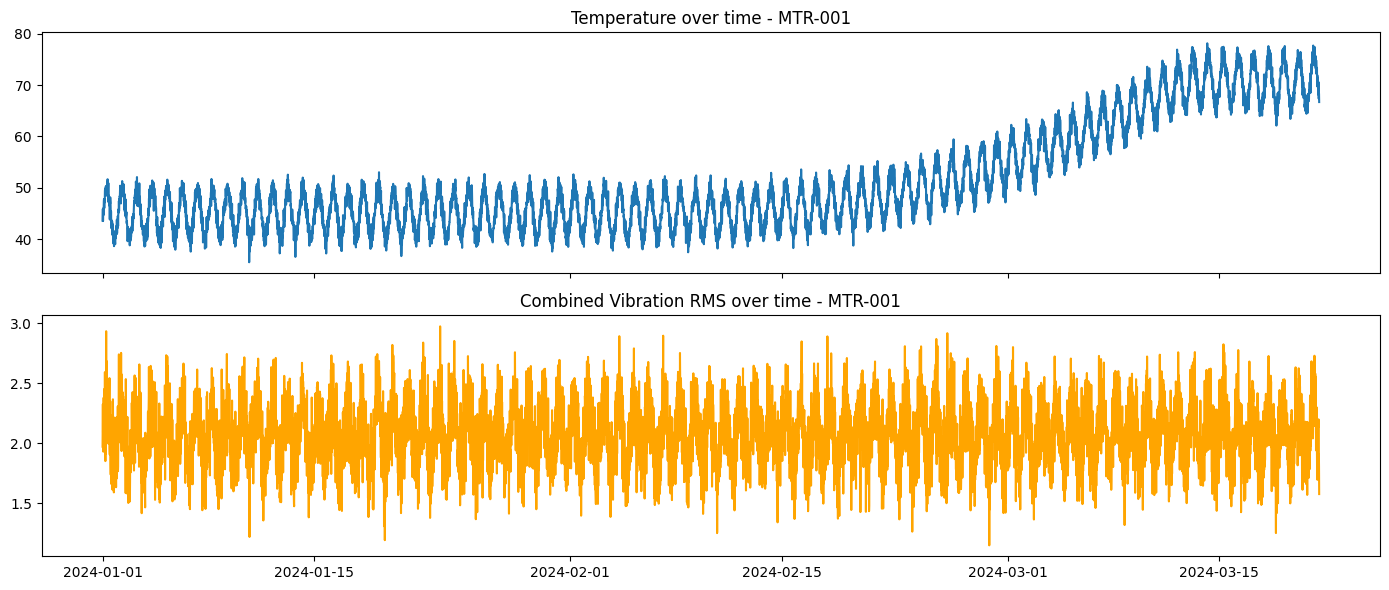

In [5]:
# Quick visual check: Temperature & combined vibration trend for one motor
sample_motor = df["Motor_ID"].unique()[0]
sub = df[df["Motor_ID"] == sample_motor]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(sub["Timestamp"], sub["Temperature"])
axes[0].set_title(f"Temperature over time - {sample_motor}")

vib_rms = np.sqrt(sub["Vibration_X"]**2 + sub["Vibration_Y"]**2 + sub["Vibration_Z"]**2)
axes[1].plot(sub["Timestamp"], vib_rms, color="orange")
axes[1].set_title(f"Combined Vibration RMS over time - {sample_motor}")

plt.tight_layout()
plt.show()

## 3. Feature Engineering

Raw data per timestamp is usually insufficient for ML - models need to see trends, not just instantaneous values. The features we're building here are:

- **Vibration_RMS_Combined**: combines X/Y/Z values ​​into a single scalar (total vibration magnitude)
- **Voltage_Imbalance_Pct**: how much deviation there is between L1/L2/L3 phases (a common indication of an electrical fault)
- **Rolling mean & std** (short & long window) for Temperature & Vibration_RMS_Combined
-> captures gradual degradation patterns, not just momentary spikes
- **Rate of change (delta)** between rows -> captures how quickly a parameter changes

All rolling is calculated **per Motor_ID** to prevent data leakage between motors.

In [6]:
def engineer_features(data: pd.DataFrame, short_window=4, long_window=24) -> pd.DataFrame:
    data = data.copy()

    # Combined vibration magnitude
    data["Vibration_RMS_Combined"] = np.sqrt(
        data["Vibration_X"]**2 + data["Vibration_Y"]**2 + data["Vibration_Z"]**2
    )

    # Voltage imbalance (% deviation from the 3-phase average)
    v_mean = data[["Voltage_L1", "Voltage_L2", "Voltage_L3"]].mean(axis=1)
    v_max_dev = data[["Voltage_L1", "Voltage_L2", "Voltage_L3"]].sub(v_mean, axis=0).abs().max(axis=1)
    data["Voltage_Imbalance_Pct"] = (v_max_dev / v_mean) * 100

    feature_cols = ["Temperature", "Vibration_RMS_Combined", "Rotational_Speed", "Voltage_Imbalance_Pct"]

    grouped = data.groupby("Motor_ID")
    for col in feature_cols:
        # Rolling mean & std -> tren jangka pendek & panjang
        data[f"{col}_roll_mean_short"] = grouped[col].transform(lambda s: s.rolling(short_window, min_periods=1).mean())
        data[f"{col}_roll_std_short"]  = grouped[col].transform(lambda s: s.rolling(short_window, min_periods=1).std().fillna(0))
        data[f"{col}_roll_mean_long"]  = grouped[col].transform(lambda s: s.rolling(long_window, min_periods=1).mean())

        # Rate of change antar baris (delta) -> seberapa cepat parameter berubah
        data[f"{col}_delta"] = grouped[col].diff().fillna(0)

    return data

df_feat = engineer_features(df)
df_feat.head()

,Timestamp,Motor_ID,Voltage_L1,Voltage_L2,Voltage_L3,Frequency,Power_Factor,Temperature,Vibration_X,Vibration_Y,Vibration_Z,Rotational_Speed,Motor_State,Fault_Type_True,RUL_hours,Health_Score,Probable_Cause,Recommended_Action,Vibration_RMS_Combined,Voltage_Imbalance_Pct,Temperature_roll_mean_short,Temperature_roll_std_short,Temperature_roll_mean_long,Temperature_delta,Vibration_RMS_Combined_roll_mean_short,Vibration_RMS_Combined_roll_std_short,Vibration_RMS_Combined_roll_mean_long,Vibration_RMS_Combined_delta,Rotational_Speed_roll_mean_short,Rotational_Speed_roll_std_short,Rotational_Speed_roll_mean_long,Rotational_Speed_delta,Voltage_Imbalance_Pct_roll_mean_short,Voltage_Imbalance_Pct_roll_std_short,Voltage_Imbalance_Pct_roll_mean_long,Voltage_Imbalance_Pct_delta
0,2024-01-01 00:00:00,MTR-001,400.99,399.88,400.39,50.07,1.0,43.63,1.212,1.131,1.064,1474.4,Normal,Normal,1554.2,62.5,-,"Normal condition, continue routine monitoring",1.969823,0.142351,43.630000,0.000000,43.630000,0.00,1.969823,0.000000,1.969823,0.000000,1474.40,0.000000,1474.40,0.0,0.142351,0.000000,0.142351,0.000000
1,2024-01-01 00:15:00,MTR-001,401.14,402.95,401.78,50.00,1.0,44.62,1.311,1.317,1.101,1474.9,Normal,Normal,1554.0,62.5,-,"Normal condition, continue routine monitoring",2.159956,0.247124,44.125000,0.700036,44.125000,0.99,2.064889,0.134445,2.064889,0.190134,1474.65,0.353553,1474.65,0.5,0.194738,0.074086,0.194738,0.104774
2,2024-01-01 00:30:00,MTR-001,399.74,397.81,398.84,50.05,1.0,45.92,1.415,1.285,1.322,1475.4,Normal,Normal,1553.8,62.5,-,"Normal condition, continue routine monitoring",2.324034,0.247411,44.723333,1.148492,44.723333,1.30,2.151271,0.177265,2.151271,0.164078,1474.90,0.500000,1474.90,0.5,0.212295,0.060574,0.212295,0.000286
3,2024-01-01 00:45:00,MTR-001,400.23,400.94,401.24,50.09,1.0,43.56,1.200,1.241,1.175,1474.5,Normal,Normal,1553.5,62.5,-,"Normal condition, continue routine monitoring",2.088230,0.143046,44.432500,1.103491,44.432500,-2.36,2.135511,0.148129,2.135511,-0.235804,1474.80,0.454606,1474.80,-0.9,0.194983,0.060374,0.194983,-0.104365
4,2024-01-01 01:00:00,MTR-001,398.06,398.26,398.16,50.08,1.0,44.98,1.307,1.269,1.345,1473.6,Normal,Normal,1553.2,62.5,-,"Normal condition, continue routine monitoring",2.264428,0.025116,44.770000,0.975226,44.542000,1.42,2.209162,0.105350,2.161294,0.176198,1474.60,0.761577,1474.56,-0.9,0.165674,0.105805,0.161010,-0.117931


## 4. RUL & Health_Score - Verification (already available in the training file)

Different from the previous version: `RUL_hours` and `Health_Score` are now directly available** in `client_training_dataset.csv`, calculated retrospectively from history (not model results).
The logic is:

- For motors that have reached the "Failure" state: RUL = the time difference from that row to the first time the motor reached "Failure" (historical failure point).
- For motors that have never failed within the observation window: RUL is considered censored (assigned the maximum observation duration, because the actual remaining life is unknown).

We saved the same function below as `compute_rul_retrospective()` - not for use on training data (which already exists), but for reusability if new historical data needs to be recalculated in the same way.

In [7]:
def compute_rul_retrospective(data: pd.DataFrame) -> pd.DataFrame:
    """Hitung RUL_hours retrospektif dari histori Motor_State per motor.
    Referensi/reusable function - TIDAK dipanggil ke df_feat karena RUL_hours
    sudah tersedia langsung dari client_training_dataset.csv."""
    data = data.copy()
    data["RUL_hours"] = np.nan

    for motor_id, sub in data.groupby("Motor_ID"):
        sub = sub.sort_values("Timestamp")
        failure_idx = sub.index[sub["Motor_State"] == "Failure"]

        if len(failure_idx) > 0:
            failure_time = sub.loc[failure_idx[0], "Timestamp"]
        else:
            failure_time = sub["Timestamp"].max()  # censored

        hours_to_failure = (failure_time - sub["Timestamp"]).dt.total_seconds() / 3600
        data.loc[sub.index, "RUL_hours"] = hours_to_failure.clip(lower=0)

    return data

# Verifikasi RUL_hours & Health_Score yang sudah ada di df_feat (dari file training)
df_feat[["Motor_ID", "Timestamp", "Motor_State", "RUL_hours", "Health_Score"]].head()

,Motor_ID,Timestamp,Motor_State,RUL_hours,Health_Score
0,MTR-001,2024-01-01 00:00:00,Normal,1554.2,62.5
1,MTR-001,2024-01-01 00:15:00,Normal,1554.0,62.5
2,MTR-001,2024-01-01 00:30:00,Normal,1553.8,62.5
3,MTR-001,2024-01-01 00:45:00,Normal,1553.5,62.5
4,MTR-001,2024-01-01 01:00:00,Normal,1553.2,62.5


## 5. Split Data (per Motor - avoid data leakage, with guaranteed representation of each class)

Because this is a per-motor time series, **don't** use a regular random shuffle (adjacent rows can leak between train and test). We split based on **Motor_ID** - certain motors are fully in the test set, others are fully in the train set.

**Important note**: The regular `StratifiedGroupKFold` can still fail if a single fault type only exists in a handful of motors (in this dataset, `Misalignment` and `Stator Winding` are only present in 3 motors each, out of 20 total motors) - the automatic stratification doesn't always work on such small groups, and that's why `support=0` still appears in the previous training. Therefore, here we split **manually by motor fault category**: each fault category is guaranteed to have at least 1 motor in the test set AND at least 1 motor in the train set, then the remainder is divided proportionally.

In [8]:
# NOTE: Probable_Cause, Recommended_Action, RUL_hours, and Health_Score are intentionally
# EXCLUDED from classification features. Probable_Cause/Recommended_Action are lookup
# tables from Fault_Type_True (not sensor signals). RUL_hours and Health_Score are
# our own REGRESSION TARGETS (and are highly correlated with Motor_State/
# Fault_Type_True) - if included as classification features, this would cause data leakage,
# the model would "cheat" by predicting labels from its own derivatives.
FEATURE_COLS = [c for c in df_feat.columns if c not in [
    "Timestamp", "Motor_ID", "Motor_State", "Fault_Type_True", "RUL_hours",
    "Health_Score", "Probable_Cause", "Recommended_Action"
]]

# Each motor has ONE "lifetime" fault type (the fault it experienced, or "Normal"
# if it never had one). We split at the motor level per this category, not randomly per motor,
# to ensure each category is GUARANTEED to appear in both train and test.
motor_category = (
    df_feat.groupby("Motor_ID")["Fault_Type_True"]
    .agg(lambda s: next(iter(set(s) - {"Normal"}), "Normal"))
)

rng_split = np.random.default_rng(42)
test_motors = []
for category, motors_in_cat in motor_category.groupby(motor_category).groups.items():
    motors_in_cat = list(motors_in_cat)
    rng_split.shuffle(motors_in_cat)
    n_test = max(1, round(len(motors_in_cat) * 0.2))
    # ensure test doesn't take ALL motors in that category (train also needs at least 1)
    n_test = min(n_test, len(motors_in_cat) - 1) if len(motors_in_cat) > 1 else 1
    test_motors.extend(motors_in_cat[:n_test])

train_motors = [m for m in motor_category.index if m not in test_motors]

train_df = df_feat[df_feat["Motor_ID"].isin(train_motors)].reset_index(drop=True)
test_df  = df_feat[df_feat["Motor_ID"].isin(test_motors)].reset_index(drop=True)

print("Train motors:", train_df["Motor_ID"].nunique(), "| Test motors:", test_df["Motor_ID"].nunique())
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("\nTrain class distribution:")
print(train_df["Fault_Type_True"].value_counts())
print("\nTest class distribution:")
print(test_df["Fault_Type_True"].value_counts())

missing_in_test = set(train_df["Fault_Type_True"].unique()) - set(test_df["Fault_Type_True"].unique())
assert not missing_in_test, f"These classes are still missing from the test set: {missing_in_test}"
print("\nAll fault classes are represented in the test set. Safe to proceed with training.")

Train motors: 15 | Test motors: 5
Train rows: 142222 | Test rows: 47053

Train class distribution:
Fault_Type_True
Normal            111283
Rotor Bar          10280
Bearing Wear        8658
Misalignment        7172
Stator Winding      4829
Name: count, dtype: int64

Test class distribution:
Fault_Type_True
Normal            35104
Rotor Bar          3967
Stator Winding     2957
Bearing Wear       2893
Misalignment       2132
Name: count, dtype: int64

All fault classes are represented in the test set. Safe to proceed with training.


## 6. Preprocessing & Scaling

Voltage (~400), Vibration (~1-9), Temperature (~35-85) are on different scales - they need to be scaled so that the model (especially the scale-sensitive one) learns proportionally.

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURE_COLS])
X_test  = scaler.transform(test_df[FEATURE_COLS])

## 7. Classification Model - Fault_Type_True

Compare the two best models commonly used for tabular data: Random Forest vs. XGBoost.
Main metric: macro F1-score (not accuracy) due to imbalanced labels (there are far more normals than each fault type).

In [10]:
y_train_clf = train_df["Fault_Type_True"]
y_test_clf  = test_df["Fault_Type_True"]

rf_clf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train_clf)
rf_pred = rf_clf.predict(X_test)

xgb_clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_clf.fit(X_train, y_train_clf.astype("category").cat.codes if False else y_train_clf.factorize()[0])
xgb_pred_codes = xgb_clf.predict(X_test)
label_map = dict(enumerate(y_train_clf.factorize()[1]))
xgb_pred = pd.Series(xgb_pred_codes).map(label_map)

print("=== Random Forest ===")
print("Macro F1:", round(f1_score(y_test_clf, rf_pred, average="macro"), 4))
print(classification_report(y_test_clf, rf_pred))

print("\n=== XGBoost ===")
print("Macro F1:", round(f1_score(y_test_clf, xgb_pred, average="macro"), 4))
print(classification_report(y_test_clf, xgb_pred))

=== Random Forest ===
Macro F1: 0.9351
                precision    recall  f1-score   support

  Bearing Wear       1.00      0.70      0.83      2893
  Misalignment       1.00      0.96      0.98      2132
        Normal       1.00      1.00      1.00     35104
     Rotor Bar       0.79      0.99      0.88      3967
Stator Winding       0.99      0.99      0.99      2957

      accuracy                           0.98     47053
     macro avg       0.96      0.93      0.94     47053
  weighted avg       0.98      0.98      0.97     47053


=== XGBoost ===
Macro F1: 0.9475
                precision    recall  f1-score   support

  Bearing Wear       1.00      0.77      0.87      2893
  Misalignment       1.00      0.95      0.97      2132
        Normal       1.00      1.00      1.00     35104
     Rotor Bar       0.84      0.99      0.91      3967
Stator Winding       1.00      0.98      0.99      2957

      accuracy                           0.98     47053
     macro avg       0.97 

In [11]:
best_clf_name = "xgboost" # <-- change to "xgboost" if XGBoost is better
best_clf = rf_clf if best_clf_name == "random_forest" else xgb_clf

# NOTE: Check using the TYPE model (not string matching) to avoid bugs due to
# typos/capitalization (e.g., writing "XGBoost" instead of "xgboost") - if using string matching
# which is case-sensitive, small typos will prevent the XGBoost prediction result from being decoded back to the original fault name (shown as code numbers 0, 1, 2,... instead of "Bearing Wear" etc.).

best_clf_is_xgboost = isinstance(best_clf, XGBClassifier)
print("Selected classification model:", best_clf_name, "| is XGBoost:", best_clf_is_xgboost)

Selected classification model: xgboost | is XGBoost: True


## 8. Regression Model - RUL (Remaining Useful Life)

Compare Random Forest Regressor vs. Gradient Boosting Regressor.
Metrics: MAE (mean hourly difference) and RMSE, plus R² to see how well the model explains the variation in RUL.

In [12]:
y_train_rul = train_df["RUL_hours"]
y_test_rul  = test_df["RUL_hours"]

rf_reg = RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train_rul)
rf_reg_pred = rf_reg.predict(X_test)

gb_reg = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
gb_reg.fit(X_train, y_train_rul)
gb_reg_pred = gb_reg.predict(X_test)

def report_regression(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.2f} hours | RMSE={rmse:.2f} hours | R2={r2:.4f}")

report_regression("Random Forest Regressor", y_test_rul, rf_reg_pred)
report_regression("Gradient Boosting Regressor", y_test_rul, gb_reg_pred)

Random Forest Regressor: MAE=369.21 hours | RMSE=535.37 hours | R2=0.4705
Gradient Boosting Regressor: MAE=363.17 hours | RMSE=517.81 hours | R2=0.5047


In [13]:
# Select the best RUL model based on the MAE/RMSE above
best_reg_name = "gradient_boosting"  # <-- change to "gradient_boosting" if it's better
best_reg = rf_reg if best_reg_name == "random_forest" else gb_reg
print("Selected RUL model:", best_reg_name)

Selected RUL model: gradient_boosting


## 9. Health Score (a simple derivative of RUL)

The Health Score is not a separate ML output—it simply normalizes the RUL predictions to a scale of 0-100 for easy display on the dashboard (100 = fully healthy, closer to 0 = closer to failure).
We use `best_reg` (the winning RUL model from the previous step), not hard-coding one.

In [14]:
RUL_REFERENCE_HOURS = train_df["RUL_hours"].quantile(0.95) 

def rul_to_health_score(rul_hours, reference=RUL_REFERENCE_HOURS):
    score = (np.asarray(rul_hours) / reference) * 100
    return np.clip(score, 0, 100).round(1)

best_reg_pred_test = best_reg.predict(X_test)
test_health_score = rul_to_health_score(best_reg_pred_test)
pd.DataFrame({
    "Motor_ID": test_df["Motor_ID"].values,
    "Timestamp": test_df["Timestamp"].values,
    "Predicted_RUL_hours": best_reg_pred_test.round(1),
    "Health_Score": test_health_score
}).head(10)

,Motor_ID,Timestamp,Predicted_RUL_hours,Health_Score
0,MTR-003,2024-01-01 00:00:00,1406.1,55.7
1,MTR-003,2024-01-01 00:15:00,971.4,38.5
2,MTR-003,2024-01-01 00:30:00,626.7,24.8
3,MTR-003,2024-01-01 00:45:00,905.7,35.9
4,MTR-003,2024-01-01 01:00:00,977.2,38.7
5,MTR-003,2024-01-01 01:15:00,977.2,38.7
6,MTR-003,2024-01-01 01:30:00,974.2,38.6
7,MTR-003,2024-01-01 01:45:00,940.6,37.3
8,MTR-003,2024-01-01 02:00:00,941.0,37.3
9,MTR-003,2024-01-01 02:15:00,971.1,38.5


## 10. Recommendation Engine (Rule-Based, based on ML results)

This is the section we requested in the final output ("2 forms: graph and recommendation").
**Important**: The recommendation here is NOT an ML result - it's a rule-based lookup table (FMEA-style)
applied ABOVE the model's prediction results (`Fault_Type_True` prediction + `Health_Score`).
The lookup table is exactly the same as the one standardized in the dataset (`Probable_Cause` and `Recommended_Action` columns), to ensure consistency between historical data and real-time prediction results.

Why not ML? Because there's no history of "actions taken -> success/failure"
to learn from. Once the company has that feedback loop (advanced production phase), the recommendation can be upgraded to a model that truly learns the effectiveness of actions.

In [15]:
RECOMMENDATION_TABLE = {
    "Normal": {
        "Probable_Cause": "-",
        "Recommended_Action": "Normal condition, continue routine monitoring",
    },
    "Rotor Bar": {
        "Probable_Cause": "Broken/cracked rotor bar due to repeated thermal stress or excessive starting frequency",
        "Recommended_Action": "Perform motor current signature analysis (MCSA) and schedule rotor inspection/teardown",
    },
    "Bearing Wear": {
        "Probable_Cause": "Inadequate lubrication, contamination, or bearing wear from excessive load",
        "Recommended_Action": "Re-lubricate or replace the bearing, check seal condition and shaft alignment",
    },
    "Misalignment": {
        "Probable_Cause": "Motor shaft misaligned with the driven load/coupling",
        "Recommended_Action": "Perform laser alignment check and correct the motor mounting position",
    },
    "Stator Winding": {
        "Probable_Cause": "Winding insulation degradation from repeated overheating or moisture contamination",
        "Recommended_Action": "Perform insulation resistance test (megger) and check the cooling system",
    },
}

def urgency_level(health_score: float) -> str:
    if health_score < 40:
        return "High - immediate action required"
    elif health_score < 70:
        return "Medium - schedule within this week"
    else:
        return "Low - routine monitoring"

def generate_recommendation(fault_type_pred: str, health_score: float, rul_hours: float) -> dict:
    ref = RECOMMENDATION_TABLE.get(fault_type_pred, RECOMMENDATION_TABLE["Normal"])
    return {
        "Fault_Type_Predicted": fault_type_pred,
        "Health_Score": round(health_score, 1),
        "Predicted_RUL_hours": round(rul_hours, 1),
        "Urgency": urgency_level(health_score),
        "Probable_Cause": ref["Probable_Cause"],
        "Recommended_Action": ref["Recommended_Action"],
    }

In [16]:
# End-to-end demo: combine classification prediction results + RUL + recommendation
clf_pred_raw = best_clf.predict(X_test)
clf_pred_labels = pd.Series(clf_pred_raw).map(label_map) if best_clf_is_xgboost \
    else pd.Series(clf_pred_raw)

demo_results = []
for i in range(10):
    demo_results.append(generate_recommendation(
        fault_type_pred=clf_pred_labels.iloc[i],
        health_score=test_health_score[i],
        rul_hours=best_reg_pred_test[i],
    ))

pd.DataFrame(demo_results)

,Fault_Type_Predicted,Health_Score,Predicted_RUL_hours,Urgency,Probable_Cause,Recommended_Action
0,Normal,55.7,1406.1,Medium - schedule within this week,-,"Normal condition, continue routine monitoring"
1,Normal,38.5,971.4,High - immediate action required,-,"Normal condition, continue routine monitoring"
2,Normal,24.8,626.7,High - immediate action required,-,"Normal condition, continue routine monitoring"
3,Normal,35.9,905.7,High - immediate action required,-,"Normal condition, continue routine monitoring"
4,Normal,38.7,977.2,High - immediate action required,-,"Normal condition, continue routine monitoring"
5,Normal,38.7,977.2,High - immediate action required,-,"Normal condition, continue routine monitoring"
6,Normal,38.6,974.2,High - immediate action required,-,"Normal condition, continue routine monitoring"
7,Normal,37.3,940.6,High - immediate action required,-,"Normal condition, continue routine monitoring"
8,Normal,37.3,941.0,High - immediate action required,-,"Normal condition, continue routine monitoring"
9,Normal,38.5,971.1,High - immediate action required,-,"Normal condition, continue routine monitoring"


## 11. Save Model + Scaler + Feature List

Save so it can be reused for serving (API/dashboard) without requiring retraining.

In [ ]:
joblib.dump(best_clf, "models/fault_classifier_model.pkl")
joblib.dump(best_reg, "models/rul_regressor_model.pkl")
joblib.dump(scaler, "models/feature_scaler.pkl")
joblib.dump(FEATURE_COLS, "models/feature_columns.pkl")
joblib.dump(label_map, "models/fault_label_map.pkl")

print("Saved: models/fault_classifier_model.pkl, models/rul_regressor_model.pkl, models/feature_scaler.pkl, models/feature_columns.pkl")

Saved: models/fault_classifier_model.pkl, models/rul_regressor_model.pkl, models/feature_scaler.pkl, models/feature_columns.pkl


## 12. Inference on New Data (raw_sensor_new_data.csv)

This is the most important simulation: how this pipeline is used in the real world, when the incoming data is **just raw sensor data, without any labels** (exactly like the data a motorcycle would send in real time from the factory). All the resulting columns (`Motor_State`, `Fault_Type_True`,
`RUL_hours`, `Health_Score`, `Probable_Cause`, `Recommended_Action`) here are **pure predictions**,
not ground truth - because there is no ground truth for this new data yet.

The flow: load raw data -> feature engineering (same function as training) -> scaling
(use a scaler that has ALREADY been fitted from training, not a new fit) -> predict fault + RUL -> calculate health score -> generate recommendation.

In [18]:
raw_new = pd.read_csv(RAW_DATA_PATH, parse_dates=["Timestamp"])
raw_new = raw_new.sort_values(["Motor_ID", "Timestamp"]).reset_index(drop=True)

# Feature engineering identical to training (function already defined in step 3)
raw_new_feat = engineer_features(raw_new)

# IMPORTANT: use scaler.transform() (not fit_transform), to keep scaling consistent
# with training distribution - never fit a new scaler on new data.
X_new = scaler.transform(raw_new_feat[FEATURE_COLS])

# Predict fault type
fault_pred_codes_or_labels = best_clf.predict(X_new)
if best_clf_is_xgboost:
    fault_pred = pd.Series(fault_pred_codes_or_labels).map(label_map)
else:
    fault_pred = pd.Series(fault_pred_codes_or_labels)

# Predict RUL
rul_pred = best_reg.predict(X_new)
health_pred = rul_to_health_score(rul_pred)

# Generate end-to-end recommendations for each row
predictions = pd.DataFrame({
    "Motor_ID": raw_new_feat["Motor_ID"].values,
    "Timestamp": raw_new_feat["Timestamp"].values,
    "Fault_Type_Predicted": fault_pred.values,
    "Predicted_RUL_hours": rul_pred.round(1),
    "Health_Score": health_pred,
})
predictions["Urgency"] = predictions["Health_Score"].apply(urgency_level)
predictions["Probable_Cause"] = predictions["Fault_Type_Predicted"].map(
    lambda f: RECOMMENDATION_TABLE.get(f, RECOMMENDATION_TABLE["Normal"])["Probable_Cause"]
)
predictions["Recommended_Action"] = predictions["Fault_Type_Predicted"].map(
    lambda f: RECOMMENDATION_TABLE.get(f, RECOMMENDATION_TABLE["Normal"])["Recommended_Action"]
)

print("Sample end-to-end prediction results on new data (without labels):")
predictions.sort_values("Health_Score").head(10)

Sample end-to-end prediction results on new data (without labels):


,Motor_ID,Timestamp,Fault_Type_Predicted,Predicted_RUL_hours,Health_Score,Urgency,Probable_Cause,Recommended_Action
189274,MTR-020,2024-04-05 21:15:00,Bearing Wear,-5.1,0.0,High - immediate action required,"Inadequate lubrication, contamination, or bear...","Re-lubricate or replace the bearing, check sea..."
120357,MTR-013,2024-04-16 05:45:00,Rotor Bar,-1.3,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...
120359,MTR-013,2024-04-16 06:15:00,Rotor Bar,-5.4,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...
120360,MTR-013,2024-04-16 06:30:00,Rotor Bar,-1.3,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...
120364,MTR-013,2024-04-16 07:30:00,Rotor Bar,-4.2,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...
120365,MTR-013,2024-04-16 07:45:00,Rotor Bar,-2.1,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...
120366,MTR-013,2024-04-16 08:00:00,Rotor Bar,-5.6,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...
120367,MTR-013,2024-04-16 08:15:00,Rotor Bar,-5.8,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...
120368,MTR-013,2024-04-16 08:30:00,Rotor Bar,-4.9,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...
120369,MTR-013,2024-04-16 08:45:00,Rotor Bar,-2.5,0.0,High - immediate action required,Broken/cracked rotor bar due to repeated therm...,Perform motor current signature analysis (MCSA...


In [19]:
# Save the prediction results - this is what the dashboard (graph + recommendation) will consume later.
predictions.to_csv("predicted_maintenance_output.csv", index=False)
print("Saved: predicted_maintenance_output.csv")

# from google.colab import files
# files.download("predicted_maintenance_output.csv")

Saved: predicted_maintenance_output.csv


## Summary of Steps & Next Steps

1. Completed - Load `client_training_dataset.csv` (complete: sensors + Motor_State 4-level + Fault_Type_True + RUL_hours + Health_Score + Probable_Cause + Recommended_Action) and quality check
2. Completed - Feature engineering (rolling statistics, delta, combined vibration, voltage imbalance)
3. Completed - Verify RUL and Health_Score (already calculated retrospectively in the file, not regenerated)
4. Completed - Split per motor per fault category (manual, ensuring all classes are represented in test set)
5. Completed - Scaling
6. Completed - Fault classification model (RF vs XGBoost) - select best macro F1
7. Completed - RUL regression model (RF vs GBR) - select best MAE/RMSE
8. Completed - Recommendation engine (rule-based, English)
9. Completed - Save models
10. Completed - **End-to-end inference on `raw_sensor_new_data.csv`** (data with no labels at all) - this is the most important part, as it is the closest simulation to real production conditions

**Next steps after this notebook:**
- When real data becomes available (not dummy data), repeat feature engineering and training with that data - the pipeline above should be reusable.
- Create a simple endpoint (Flask/FastAPI) that loads these pkl models for real-time prediction serving to the dashboard, called together with `generate_recommendation()` above.
- Add **early warning alert** feature - set thresholds on Health_Score (e.g., < 40 = alert) and trigger notifications.
- Once the company has a real feedback loop (actions taken -> success/failure), the current rule-based `RECOMMENDATION_TABLE` can be upgraded to a model that learns action effectiveness from historical data.
- A chatbot recommendation feature can be a separate layer on top of the `generate_recommendation()` output (using an LLM to translate outputs into more conversational natural language).